<a href="https://colab.research.google.com/github/ha-thao/31251024728_HaPhuongThao_BTapAIBuoi1/blob/main/BT_AI_BUOI_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install numpy scikit-fuzzy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 17.3 MB/s eta 0:00:00



--- HE THONG DINH GIA & THUONG GRAB-BIKE ---

Ket qua danh gia cho cac truong hop thu nghiem:

--- TH1: Ngan - Ket xe - Mua to - Nhu cau cao ---
Gia cuoc: 76.33 / 100
Diem thuong: 88.51 / 100

--- TH2: Rat xa - Thong thoang - Troi dep - Nhu cau thap ---
Gia cuoc: 46.11 / 100
Diem thuong: 90.97 / 100

--- TH3: Trung binh - Ket xe vua - Mua nhe - Rating kem - Tre gio ---
Gia cuoc: 45.48 / 100
Diem thuong: 10.56 / 100

--- BIEU DO MO PHONG (CHO TRUONG HOP THU NGHIEM DAU TIEN) ---


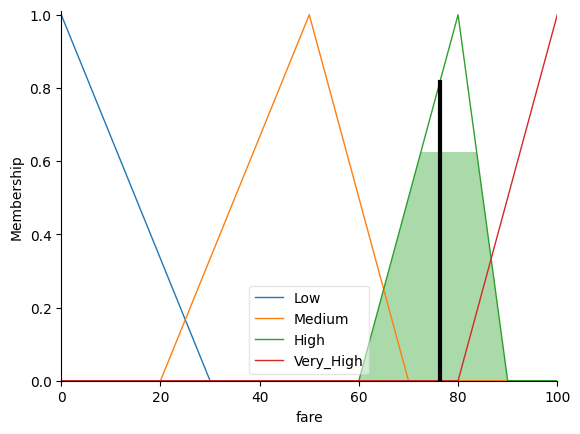

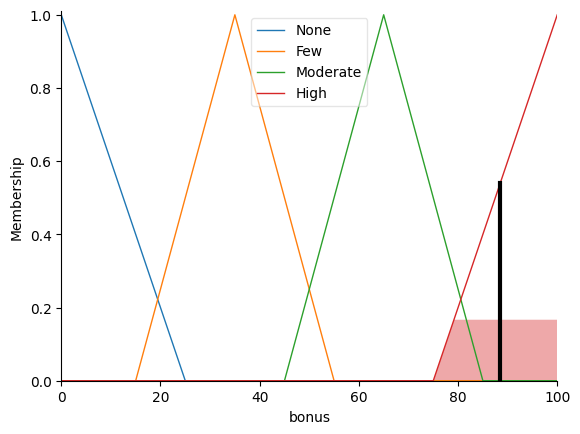

In [24]:
#2.11
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')

fare = ctrl.Consequent(np.arange(0, 101, 1), 'fare')
bonus = ctrl.Consequent(np.arange(0, 101, 1), 'bonus')

distance['Short'] = fuzz.trapmf(distance.universe, [0, 0, 2, 3])
distance['Medium'] = fuzz.trimf(distance.universe, [2, 4.5, 7])
distance['Long'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['Very_Long'] = fuzz.trapmf(distance.universe, [15, 30, 50, 50])

traffic['Low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['Medium'] = fuzz.trimf(traffic.universe, [20, 45, 70])
traffic['High'] = fuzz.trimf(traffic.universe, [60, 100, 100])

demand['Low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['Medium'] = fuzz.trimf(demand.universe, [20, 45, 70])
demand['High'] = fuzz.trimf(demand.universe, [60, 100, 100])

weather['Good'] = fuzz.trimf(weather.universe, [0, 0, 4])
weather['Moderate'] = fuzz.trimf(weather.universe, [3, 5, 7])
weather['Bad'] = fuzz.trimf(weather.universe, [6, 10, 10])

rating['Poor'] = fuzz.trimf(rating.universe, [1.0, 1.0, 2.5])
rating['Average'] = fuzz.trimf(rating.universe, [2.5, 3.25, 4.0])
rating['Good'] = fuzz.trimf(rating.universe, [3.5, 5.0, 5.0])

punctuality['Late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['On_Time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['Early'] = fuzz.trimf(punctuality.universe, [70, 100, 100])

fare['Low'] = fuzz.trimf(fare.universe, [0, 0, 30])
fare['Medium'] = fuzz.trimf(fare.universe, [20, 50, 70])
fare['High'] = fuzz.trimf(fare.universe, [60, 80, 90])
fare['Very_High'] = fuzz.trimf(fare.universe, [80, 100, 100])

bonus['None'] = fuzz.trimf(bonus.universe, [0, 0, 25])
bonus['Few'] = fuzz.trimf(bonus.universe, [15, 35, 55])
bonus['Moderate'] = fuzz.trimf(bonus.universe, [45, 65, 85])
bonus['High'] = fuzz.trimf(bonus.universe, [75, 100, 100])

fare_rules = [
    ctrl.Rule(distance['Short'] & traffic['Low'] & demand['Low'], fare['Low']),
    ctrl.Rule(distance['Short'] & traffic['Medium'] & demand['High'], fare['Medium']),
    ctrl.Rule(distance['Medium'] & traffic['High'] & demand['High'], fare['High']),
    ctrl.Rule(distance['Long'] & traffic['Medium'] & weather['Good'], fare['Medium']),
    ctrl.Rule(distance['Long'] & traffic['High'] & weather['Bad'], fare['Very_High']),
    ctrl.Rule(distance['Very_Long'] & traffic['High'] & demand['High'], fare['Very_High']),
    ctrl.Rule(distance['Medium'] & traffic['Low'] & demand['Low'], fare['Medium']),
    ctrl.Rule(distance['Short'] & traffic['High'] & weather['Bad'], fare['High']),
    ctrl.Rule(distance['Very_Long'] & weather['Bad'], fare['Very_High']),
    ctrl.Rule(distance['Medium'] & traffic['Medium'] & weather['Moderate'], fare['Medium']),
    # Re-adding the rule to cover the specific input combination from the failing test case
    ctrl.Rule(distance['Very_Long'] & traffic['Low'] & demand['Low'] & weather['Good'], fare['Medium'])
]

bonus_rules = [
    ctrl.Rule(rating['Good'] & punctuality['Early'], bonus['High']),
    ctrl.Rule(rating['Average'] & punctuality['On_Time'], bonus['Moderate']),
    ctrl.Rule(rating['Poor'] & punctuality['Late'], bonus['None']),
    ctrl.Rule(distance['Long'] & traffic['High'] & punctuality['On_Time'], bonus['High']),
    ctrl.Rule(distance['Medium'] & traffic['Medium'] & rating['Good'], bonus['Moderate']),
    ctrl.Rule(distance['Very_Long'] & weather['Bad'] & rating['Good'], bonus['High']),
    ctrl.Rule(distance['Short'] & rating['Average'] & punctuality['On_Time'], bonus['Few']),
    ctrl.Rule(distance['Long'] & traffic['High'] & punctuality['Late'], bonus['Few']),
    ctrl.Rule(distance['Medium'] & weather['Moderate'] & rating['Good'], bonus['Moderate'])
]

fare_ctrl = ctrl.ControlSystem(fare_rules)
fare_sim = ctrl.ControlSystemSimulation(fare_ctrl)

bonus_ctrl = ctrl.ControlSystem(bonus_rules)
bonus_sim = ctrl.ControlSystemSimulation(bonus_ctrl)

print("\n--- HE THONG DINH GIA & THUONG GRAB-BIKE ---")
print("\nKet qua danh gia cho cac truong hop thu nghiem:")

test_cases = [
    {
        "name": "TH1: Ngan - Ket xe - Mua to - Nhu cau cao",
        "fare_input": {'distance': 1.5, 'traffic': 85, 'demand': 90, 'weather': 9},
        "bonus_input": {'distance': 1.5, 'traffic': 85, 'weather': 9, 'rating': 4.8, 'punctuality': 75}
    },
    {
        "name": "TH2: Rat xa - Thong thoang - Troi dep - Nhu cau thap",
        "fare_input": {'distance': 45, 'traffic': 15, 'demand': 10, 'weather': 1},
        "bonus_input": {'distance': 45, 'traffic': 15, 'weather': 1, 'rating': 4.5, 'punctuality': 95}
    },
    {
        "name": "TH3: Trung binh - Ket xe vua - Mua nhe - Rating kem - Tre gio",
        "fare_input": {'distance': 5, 'traffic': 65, 'demand': 50, 'weather': 6},
        "bonus_input": {'distance': 5, 'traffic': 65, 'weather': 6, 'rating': 2.0, 'punctuality': 30}
    }
]

for case in test_cases:
    print(f"\n--- {case['name']} ---")

    for k, v in case['fare_input'].items():
        fare_sim.input[k] = v
    fare_sim.compute()
    print(f"Gia cuoc: {fare_sim.output['fare']:.2f} / 100")

    for k, v in case['bonus_input'].items():
        bonus_sim.input[k] = v
    bonus_sim.compute()
    print(f"Diem thuong: {bonus_sim.output['bonus']:.2f} / 100")

print("\n--- BIEU DO MO PHONG (CHO TRUONG HOP THU NGHIEM DAU TIEN) ---")

for k, v in test_cases[0]['fare_input'].items():
    fare_sim.input[k] = v
fare_sim.compute()

for k, v in test_cases[0]['bonus_input'].items():
    bonus_sim.input[k] = v
bonus_sim.compute()

fare.view(sim=fare_sim)
bonus.view(sim=bonus_sim)
plt.show()

Xep hang cua hang: 4.3/5.0
Khoi luong ban hang: 50/100
Bien loi nhuan: 15/100
Su kien theo mua: 9.5/10
Chiet khau doi thu: 85/100
Muc chiet khau de xuat: 57.20%
Phan loai: Rat cao (40-70%)


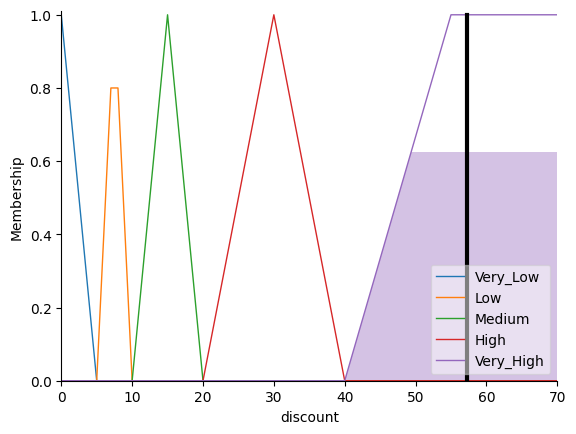

In [22]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

store_rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_event')
competitor_discounts = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_discounts')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

store_rating['Low'] = fuzz.trapmf(store_rating.universe, [1.0, 1.0, 3.8, 4.1])
store_rating['Medium'] = fuzz.trimf(store_rating.universe, [4.0, 4.25, 4.5])
store_rating['High'] = fuzz.trapmf(store_rating.universe, [4.4, 4.6, 5.0, 5.0])

sales_volume['Low'] = fuzz.trimf(sales_volume.universe, [0, 0, 40])
sales_volume['Medium'] = fuzz.trimf(sales_volume.universe, [30, 50, 70])
sales_volume['High'] = fuzz.trimf(sales_volume.universe, [60, 100, 100])

profit_margin['Low'] = fuzz.trimf(profit_margin.universe, [0, 0, 35])
profit_margin['Medium'] = fuzz.trimf(profit_margin.universe, [25, 50, 75])
profit_margin['High'] = fuzz.trimf(profit_margin.universe, [65, 100, 100])

seasonal_event['None'] = fuzz.trimf(seasonal_event.universe, [0, 0, 3])
seasonal_event['Moderate'] = fuzz.trimf(seasonal_event.universe, [2, 5, 8])
seasonal_event['High'] = fuzz.trimf(seasonal_event.universe, [7, 10, 10])

competitor_discounts['Low'] = fuzz.trimf(competitor_discounts.universe, [0, 0, 30])
competitor_discounts['Medium'] = fuzz.trimf(competitor_discounts.universe, [20, 50, 75])
competitor_discounts['High'] = fuzz.trimf(competitor_discounts.universe, [60, 100, 100])

discount['Very_Low'] = fuzz.trimf(discount.universe, [0, 2.5, 5])
discount['Low'] = fuzz.trimf(discount.universe, [5, 7.5, 10])
discount['Medium'] = fuzz.trimf(discount.universe, [10, 15, 20])
discount['High'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['Very_High'] = fuzz.trapmf(discount.universe, [40, 55, 70, 70])

rules = [
    ctrl.Rule(store_rating['High'] & sales_volume['High'] & profit_margin['High'], discount['Very_Low']),
    ctrl.Rule(store_rating['Low'] & sales_volume['Low'] & profit_margin['High'], discount['High']),
    ctrl.Rule(seasonal_event['High'] & competitor_discounts['High'], discount['Very_High']),
    ctrl.Rule(store_rating['Medium'] & sales_volume['Medium'] & profit_margin['Medium'], discount['Medium']),
    ctrl.Rule(competitor_discounts['Low'] & profit_margin['Low'] & sales_volume['High'], discount['Very_Low']),
    ctrl.Rule(store_rating['Low'] & seasonal_event['None'], discount['Medium']),
    ctrl.Rule(sales_volume['Low'] & profit_margin['Low'], discount['High']),
]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['store_rating'] = 4.3
discount_sim.input['sales_volume'] = 50
discount_sim.input['profit_margin'] = 15
discount_sim.input['seasonal_event'] = 9.5
discount_sim.input['competitor_discounts'] = 85

discount_sim.compute()

result = discount_sim.output['discount']

print(f"Xep hang cua hang: 4.3/5.0")
print(f"Khoi luong ban hang: 50/100")
print(f"Bien loi nhuan: 15/100")
print(f"Su kien theo mua: 9.5/10")
print(f"Chiet khau doi thu: 85/100")
print(f"Muc chiet khau de xuat: {result:.2f}%")

if 0 <= result <= 5:
    print("Phan loai: Rat thap (0-5%)")
elif 5 < result <= 10:
    print("Phan loai: Thap (5-10%)")
elif 10 < result <= 20:
    print("Phan loai: Trung binh (10-20%)")
elif 20 < result <= 40:
    print("Phan loai: Cao (20-40%)")
elif 40 < result <= 70:
    print("Phan loai: Rat cao (40-70%)")

discount.view(sim=discount_sim)
plt.grid(True)
plt.show()


San pham: Dong ho xa xi thu cong
Nhu cau san pham: 85/100 (Cao)
Ap luc dinh gia doi thu: 50/100 (Trung binh)
Uy tin cua hang: 4.2/5.0 (Trung binh)
Bien loi nhuan: 80/100 (Cao)
Nhu cau theo mua: 9.5/10 (Cao)
Muc chiet khau de xuat: 20.00%
Phan loai: Trung binh (10-20%)


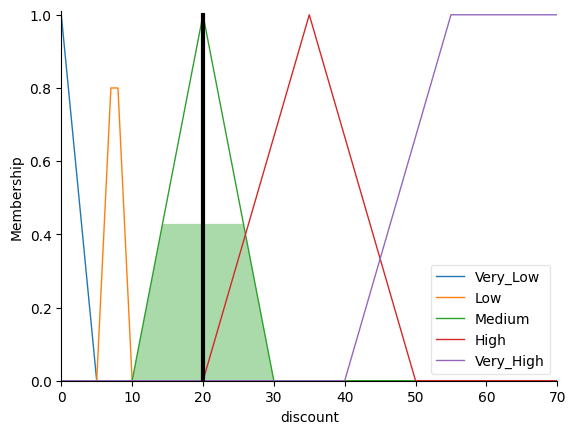

In [27]:
#2.13
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

product_demand = ctrl.Antecedent(np.arange(0, 101, 1), 'product_demand')
competitor_pressure = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_pressure')
store_reputation = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'store_reputation')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_demand = ctrl.Antecedent(np.arange(0, 11, 1), 'seasonal_demand')

discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')

product_demand['Low'] = fuzz.trimf(product_demand.universe, [0, 0, 40])
product_demand['Medium'] = fuzz.trimf(product_demand.universe, [30, 50, 70])
product_demand['High'] = fuzz.trimf(product_demand.universe, [60, 100, 100])

competitor_pressure['Low'] = fuzz.trimf(competitor_pressure.universe, [0, 0, 35])
competitor_pressure['Medium'] = fuzz.trimf(competitor_pressure.universe, [25, 50, 75])
competitor_pressure['High'] = fuzz.trimf(competitor_pressure.universe, [65, 100, 100])

store_reputation['Low'] = fuzz.trapmf(store_reputation.universe, [1.0, 1.0, 3.8, 4.0])
store_reputation['Medium'] = fuzz.trimf(store_reputation.universe, [3.9, 4.25, 4.5])
store_reputation['High'] = fuzz.trapmf(store_reputation.universe, [4.4, 4.6, 5.0, 5.0])

profit_margin['Low'] = fuzz.trimf(profit_margin.universe, [0, 0, 35])
profit_margin['Medium'] = fuzz.trimf(profit_margin.universe, [25, 50, 75])
profit_margin['High'] = fuzz.trimf(profit_margin.universe, [65, 100, 100])

seasonal_demand['None'] = fuzz.trimf(seasonal_demand.universe, [0, 0, 3])
seasonal_demand['Moderate'] = fuzz.trimf(seasonal_demand.universe, [2, 5, 8])
seasonal_demand['High'] = fuzz.trimf(seasonal_demand.universe, [7, 10, 10])

discount['Very_Low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['Low'] = fuzz.trimf(discount.universe, [5, 7.5, 10])
discount['Medium'] = fuzz.trimf(discount.universe, [10, 20, 30])
discount['High'] = fuzz.trimf(discount.universe, [20, 35, 50])
discount['Very_High'] = fuzz.trapmf(discount.universe, [40, 55, 70, 70])

rules = [
    ctrl.Rule(product_demand['High'] & competitor_pressure['Low'] & profit_margin['Low'], discount['Very_Low']),
    ctrl.Rule(product_demand['Low'] & competitor_pressure['High'] & profit_margin['High'], discount['High']),
    ctrl.Rule(store_reputation['High'] & profit_margin['Medium'] & seasonal_demand['High'], discount['Medium']),
    ctrl.Rule(competitor_pressure['High'] & seasonal_demand['High'] & profit_margin['High'], discount['Very_High']),
    ctrl.Rule(store_reputation['Low'] & product_demand['Medium'] & profit_margin['Low'], discount['Medium']),
    ctrl.Rule(product_demand['High'] & seasonal_demand['None'] & competitor_pressure['Low'], discount['Very_Low']),
    ctrl.Rule(profit_margin['High'] & competitor_pressure['Medium'] & seasonal_demand['High'], discount['Medium'])
]

discount_ctrl = ctrl.ControlSystem(rules)
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['product_demand'] = 85
discount_sim.input['competitor_pressure'] = 50
discount_sim.input['store_reputation'] = 4.2
discount_sim.input['profit_margin'] = 80
discount_sim.input['seasonal_demand'] = 9.5

discount_sim.compute()
result = discount_sim.output['discount']

print(f"San pham: Dong ho xa xi thu cong")
print(f"Nhu cau san pham: 85/100 (Cao)")
print(f"Ap luc dinh gia doi thu: 50/100 (Trung binh)")
print(f"Uy tin cua hang: 4.2/5.0 (Trung binh)")
print(f"Bien loi nhuan: 80/100 (Cao)")
print(f"Nhu cau theo mua: 9.5/10 (Cao)")
print(f"Muc chiet khau de xuat: {result:.2f}%")

if result <= 5:
    print("Phan loai: Rat thap (0-5%)")
elif result <= 10:
    print("Phan loai: Thap (5-10%)")
elif result <= 20:
    print("Phan loai: Trung binh (10-20%)")
elif result <= 40:
    print("Phan loai: Cao (20-40%)")
else:
    print("Phan loai: Rat cao (40-70%)")

discount.view(sim=discount_sim)
plt.show()

Mat do don hang: 85/100 (Cao)
Muc do khan cap giao hang: 50/100 (Trung binh)
Tai trong hien tai cua tai xe: 20/100 (Thap)
Tinh trang giao thong: 50/100 (Trung binh)
Loi nhuan moi lan giao hang: 50/100 (Trung binh)
So luong don hang can ket hop: 4.00 don
Muc do uu tien giao hang: 50.00/100
Uu tien: Trung binh


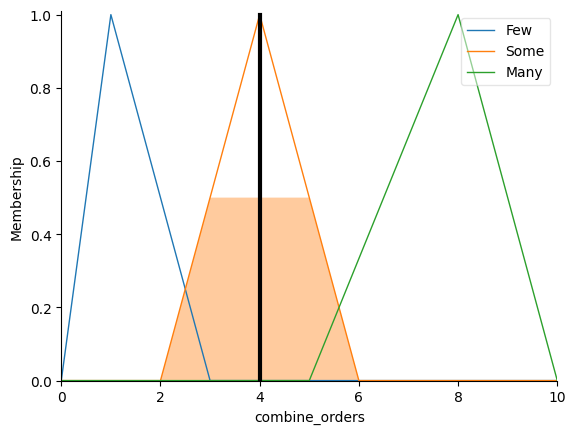

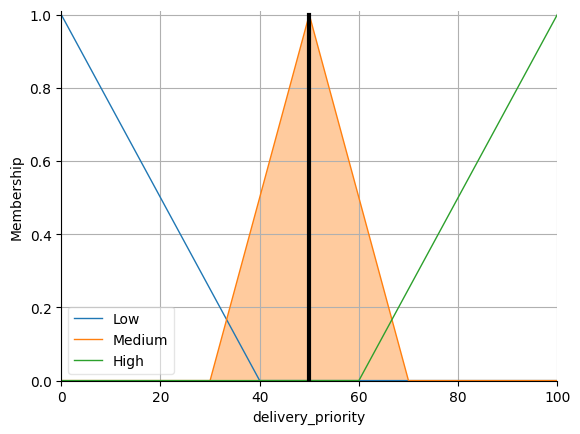

In [31]:
#2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')
delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'delivery_urgency')
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
traffic_conditions = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic_conditions')
profit_per_delivery = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_per_delivery')

combine_orders = ctrl.Consequent(np.arange(0, 11, 1), 'combine_orders')
delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'delivery_priority')

order_density['Low'] = fuzz.trimf(order_density.universe, [0, 0, 40])
order_density['Medium'] = fuzz.trimf(order_density.universe, [30, 50, 70])
order_density['High'] = fuzz.trimf(order_density.universe, [60, 100, 100])

delivery_urgency['Low'] = fuzz.trimf(delivery_urgency.universe, [0, 0, 40])
delivery_urgency['Medium'] = fuzz.trimf(delivery_urgency.universe, [30, 50, 70])
delivery_urgency['High'] = fuzz.trimf(delivery_urgency.universe, [60, 100, 100])

driver_load['Low'] = fuzz.trimf(driver_load.universe, [0, 0, 40])
driver_load['Medium'] = fuzz.trimf(driver_load.universe, [30, 50, 70])
driver_load['High'] = fuzz.trimf(driver_load.universe, [60, 100, 100])

traffic_conditions['Low'] = fuzz.trimf(traffic_conditions.universe, [0, 0, 40])
traffic_conditions['Medium'] = fuzz.trimf(traffic_conditions.universe, [30, 50, 70])
traffic_conditions['High'] = fuzz.trimf(traffic_conditions.universe, [60, 100, 100])

profit_per_delivery['Low'] = fuzz.trimf(profit_per_delivery.universe, [0, 0, 40])
profit_per_delivery['Medium'] = fuzz.trimf(profit_per_delivery.universe, [30, 50, 70])
profit_per_delivery['High'] = fuzz.trimf(profit_per_delivery.universe, [60, 100, 100])

combine_orders['Few'] = fuzz.trimf(combine_orders.universe, [0, 1, 3])
combine_orders['Some'] = fuzz.trimf(combine_orders.universe, [2, 4, 6])
combine_orders['Many'] = fuzz.trimf(combine_orders.universe, [5, 8, 10])

delivery_priority['Low'] = fuzz.trimf(delivery_priority.universe, [0, 0, 40])
delivery_priority['Medium'] = fuzz.trimf(delivery_priority.universe, [30, 50, 70])
delivery_priority['High'] = fuzz.trimf(delivery_priority.universe, [60, 100, 100])

rules = [
    ctrl.Rule(order_density['High'] & driver_load['Low'] & traffic_conditions['Low'], combine_orders['Many']),
    ctrl.Rule(order_density['Medium'] & traffic_conditions['High'] & delivery_urgency['Medium'], combine_orders['Some']),
    ctrl.Rule(driver_load['High'] & order_density['High'] & profit_per_delivery['Medium'], combine_orders['Some']),
    ctrl.Rule(order_density['Low'] & delivery_urgency['High'] & traffic_conditions['Medium'], combine_orders['Some']),
    ctrl.Rule(profit_per_delivery['High'] & delivery_urgency['High'] & traffic_conditions['High'], combine_orders['Some']),
    ctrl.Rule(delivery_urgency['High'] & profit_per_delivery['High'], delivery_priority['High']),
    ctrl.Rule(delivery_urgency['Medium'] & traffic_conditions['Medium'], delivery_priority['Medium']),
    ctrl.Rule(delivery_urgency['Low'] & order_density['High'] & profit_per_delivery['Low'], delivery_priority['Low']),
    ctrl.Rule(order_density['High'] & driver_load['Low'] & traffic_conditions['Medium'], combine_orders['Some'])
]

logistics_ctrl = ctrl.ControlSystem(rules)
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)

logistics_sim.input['order_density'] = 85
logistics_sim.input['delivery_urgency'] = 50
logistics_sim.input['driver_load'] = 20
logistics_sim.input['traffic_conditions'] = 50
logistics_sim.input['profit_per_delivery'] = 50

logistics_sim.compute()
output_combine = logistics_sim.output['combine_orders']
output_priority = logistics_sim.output['delivery_priority']

print(f"Mat do don hang: 85/100 (Cao)")
print(f"Muc do khan cap giao hang: 50/100 (Trung binh)")
print(f"Tai trong hien tai cua tai xe: 20/100 (Thap)")
print(f"Tinh trang giao thong: 50/100 (Trung binh)")
print(f"Loi nhuan moi lan giao hang: 50/100 (Trung binh)")
print(f"So luong don hang can ket hop: {output_combine:.2f} don")
print(f"Muc do uu tien giao hang: {output_priority:.2f}/100")

if 0 <= output_priority <= 40:
    print("Uu tien: Thap")
elif 40 < output_priority <= 70:
    print("Uu tien: Trung binh")
elif 70 < output_priority <= 100:
    print("Uu tien: Cao")

combine_orders.view(sim=logistics_sim)
delivery_priority.view(sim=logistics_sim)
plt.grid(True)
plt.show()
